In [32]:
#load libraries
library(tidyverse) 
library(sf) # Simple Features - a standardized way to encode spatial vector data, to read in (st_read) spatial vector data

In [33]:
# Load dataset #1 - the PEC table comes from the Piedmont Environmental Council website: https://www.pecva.org/region/culpeper/existing-and-proposed-data-centers-a-web-map/
data_centers <- read.csv ("/home/user/Capstone/data_center_research_r/data/processed/PEC_table-1.csv")

# Display first few rows of the dataset
head(data_centers)

# Get the dimensions of the dataframe
dim(data_centers)

# Examine the variables of the dataset
names(data_centers)

# Examine the structure of the dataset
str(data_centers)

,OBJECTID,PEC_ID,Locality,Name,Owner_Applicant,Street_Address,Parcel_ID,Acres,Building_Sq_Ft,MW_reported,⋯,Build_Status,Notes,Tax_Map_link,Source_link,Lat,Long,Date_Updated,Updated_By,Lat1,Watershed
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,⋯,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<lgl>
1,1,PEC-CAR-0001/PEC-SPO-0003,Caroline County,Mattameade Tech Campus,Amazon Data Services Inc,Stonewall Jackson Road just east of the Mudd Tavern,27-A-4A,916.07,"4,500,000",NA,⋯,Proposed,Sister property to Spotsylvania campus- represents total square footage,,https://co.caroline.va.us/DocumentCenter/View/7255/RZ-02-2023-Orrock-Tech-Camus?bidId=,38.11465,-77.49115,2024-04-10,SEP,38.11465,NA
2,2,PEC-CAR-0002,Caroline County,VALCO Data Center Park,VALCO CAROLINE COUNTY,Mt Airy Road,80-A-43,855.00,"1,216,000",NA,⋯,Proposed,"Project covers more than one parcel, the acreage represents the combined acreage",,https://co.caroline.va.us/AgendaCenter/ViewFile/Item/5593?fileID=9447,37.92410,-77.54387,2024-04-10,SEP,37.92410,NA
3,3,PEC-CAR-0003,Caroline County,Carmel Church Data Hub,W & F PARTNERS,Welcom Way Dr,82-14-A,97.00,"1,600,000",NA,⋯,Proposed,"Project covers more than one parcel, the acreage represents the combined acreage",,https://co.caroline.va.us/DocumentCenter/View/9366/RZ-03-2023--Carmel-Church-Data-Hub,37.93933,-77.47797,2024-04-10,SEP,37.93933,NA
4,4,PEC-CHE-0001,Chesterfield County,Digital Fortress: Richmond,CHIRISA RICHMOND LLC,1401 MEADOWVILLE TECH PARKWAY,823657720300000,74.80,"242,042",25,⋯,Existing,Formerly a Capital One data center - vacated and for sale,https://www.chesterfield.gov/828/Real-Estate-Assessment-Data#/Details/823657720300000,,37.36048,-77.32741,2024-04-10,SEP,37.36048,NA
5,5,PEC-CHE-0002,Chesterfield County,Virginia Information Technologies Agency,SLK GLOBAL SOLUTIONS AMERICA,11751 MEADOWVILLE LANE,822656429800000,28.14,"192,195",NA,⋯,Existing,,https://www.chesterfield.gov/828/Real-Estate-Assessment-Data#/Details/822656429800000,,37.36041,-77.33178,2024-04-10,SEP,37.36041,NA
6,6,PEC-CUL-0001,Culpeper County,Equinix,EQUINIX LLC,18155 TECHNOLOGY DR,51-83A1,30.12,"370,000",NA,⋯,Existing,,https://gis.vgsi.com/culpeperva/Parcel.aspx?pid=10680,,38.45494,-77.97828,2024-04-10,SEP,38.45494,NA


[1] 416  21

[1] "OBJECTID"          "PEC_ID"            "Locality"         
 [4] "Name"              "Owner_Applicant"   "Street_Address"   
 [7] "Parcel_ID"         "Acres"             "Building_Sq_Ft"   
[10] "MW_reported"       "Construction_Type" "Build_Status"     
[13] "Notes"             "Tax_Map_link"      "Source_link"      
[16] "Lat"               "Long"              "Date_Updated"     
[19] "Updated_By"        "Lat1"              "Watershed"

'data.frame':	416 obs. of  21 variables:
 $ OBJECTID         : int  1 2 3 4 5 6 7 8 9 10 ...
 $ PEC_ID           : chr  "PEC-CAR-0001/PEC-SPO-0003" "PEC-CAR-0002" "PEC-CAR-0003" "PEC-CHE-0001" ...
 $ Locality         : chr  "Caroline County" "Caroline County" "Caroline County" "Chesterfield County" ...
 $ Name             : chr  "Mattameade Tech Campus" "VALCO Data Center Park" "Carmel Church Data Hub" "Digital Fortress: Richmond" ...
 $ Owner_Applicant  : chr  "Amazon Data Services Inc" "VALCO CAROLINE COUNTY" "W & F PARTNERS" "CHIRISA RICHMOND LLC" ...
 $ Street_Address   : chr  "Stonewall Jackson Road just east of the Mudd Tavern" "Mt Airy Road" "Welcom Way Dr" "1401 MEADOWVILLE TECH PARKWAY" ...
 $ Parcel_ID        : chr  "27-A-4A" "80-A-43" "82-14-A" "823657720300000" ...
 $ Acres            : num  916.1 855 97 74.8 28.1 ...
 $ Building_Sq_Ft   : chr  "4,500,000" "1,216,000" "1,600,000" "242,042" ...
 $ MW_reported      : num  NA NA NA 25 NA NA NA NA NA NA ...
 $ Construction_Type

In [34]:
#Create new dataframe
data_centers_clean <- as.data.frame(data_centers)

#Rename variables
data_centers_clean <- data_centers_clean %>%
  rename(
    object_id = OBJECTID,
    pec_id = PEC_ID,
    locality = Locality,
    name = Name,
    owner_applicant = Owner_Applicant,
    street_address = Street_Address,
    parcel_id = Parcel_ID,
    acres = Acres,
    building_sq_ft = Building_Sq_Ft,
    mw_reported = MW_reported,
    construction_type = Construction_Type,
    build_status = Build_Status,
    notes = Notes,
    tax_map_link = Tax_Map_link,
    source_link = Source_link,
    lat = Lat,
    long = Long,
    date_updated = Date_Updated,
    updated_by = Updated_By,
    lat1 = Lat1,
    watershed = Watershed,
  )

#list the renames
names(data_centers_clean)

[1] "object_id"         "pec_id"            "locality"         
 [4] "name"              "owner_applicant"   "street_address"   
 [7] "parcel_id"         "acres"             "building_sq_ft"   
[10] "mw_reported"       "construction_type" "build_status"     
[13] "notes"             "tax_map_link"      "source_link"      
[16] "lat"               "long"              "date_updated"     
[19] "updated_by"        "lat1"              "watershed"

In [35]:
# Examine rows with missing longitude and latitude coordinates, blank space after the comma means "keep all columns"

data_centers_clean[is.na(data_centers_clean$long) | is.na(data_centers_clean$lat), ]

# Keep rows where long and lat exists

data_centers_clean <- data_centers_clean %>%
  filter(!is.na(long) & !is.na(lat))

,object_id,pec_id,locality,name,owner_applicant,street_address,parcel_id,acres,building_sq_ft,mw_reported,⋯,build_status,notes,tax_map_link,source_link,lat,long,date_updated,updated_by,lat1,watershed
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,⋯,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<lgl>
399,458,PEC-LDN-0132A,Loudoun County,PROJECT ASPEN,HAYDEN TECHNOLOGIES LLC,20491 GOOSE LANDING LN,194498227000,0.00,324890,NA,⋯,Proposed,,https://reparcelasmt.loudoun.gov/pt/Datalets/Datalet.aspx?UseSearch=no&mode=profileall&pin=194498227000&jur=107&taxyr=2024,https://loudouncountyvaeg.tylerhost.net/prod/selfservice#/plan/e48043e8-fdbb-4e91-aa87-60d35cb71173?tab=attachments,NA,-77.53495,2025-08-11,SEP,NA,NA
411,475,PEC-LDN-0157,Loudoun County,MERCURE BUSINESS PARK LOT 22,L22 LLC/ John Cox,"44211 MERCURE CIR , STERLING",091493983000,5.49,"95,658",NA,⋯,Proposed,Currently flex warehouse. Current building completed in 2022,https://reparcelasmt.loudoun.gov/pt/Datalets/Datalet.aspx?UseSearch=no&mode=profileall&pin=091493983000&jur=107&taxyr=2025,https://loudouncountyvaeg.tylerhost.net/prod/selfservice#/plan/a037a799-691c-42c4-a3fa-dd41c9dfa911?tab=attachments,NA,NA,2025-10-17,SEP,NA,NA


In [36]:
# Load dataset #2 -  the air site dataset comes from the Virginia DEQ website

# Import CSV file on air_sites in Virginia
air_sites <- read.csv ("/home/user/Capstone/data_center_research_r/data/processed/active_air_sites.csv")

# Get the dimensions of the dataframe
dim(air_sites)

# Examine the variables of the dataset
names(air_sites)

# Examine the structure of the dataset
str(air_sites)

[1] 3706   18

[1] "X"                     "Y"                     "OBJECTID"             
 [4] "PLA_ID"                "PLA_REG_NUM"           "PLA_NAME"             
 [7] "FAC_L_ADDR_1"          "FAC_L_CITY"            "FAC_L_STATE"          
[10] "FAC_L_ZIP5"            "PLA_NAC_CODE_PRIMARY"  "PLA_PRINCIPAL_PRODUCT"
[13] "PLA_ICIS_ID"           "PLA_DESC"              "PCL_STATE_DESC"       
[16] "AIR_OP_STATUS"         "PCL_FED_DESC"          "Data_Disclaimer"

'data.frame':	3706 obs. of  18 variables:
 $ X                    : num  -8620206 -8629624 -8615785 -8662972 -8737022 ...
 $ Y                    : num  4539851 4524848 4481733 4481398 4445000 ...
 $ OBJECTID             : int  1 2 3 4 5 6 7 8 9 10 ...
 $ PLA_ID               : int  34376 34441 34087 40193 34976 34942 34551 40969 39695 40330 ...
 $ PLA_REG_NUM          : int  51065 50957 50831 52155 30961 30926 30326 81617 73316 73448 ...
 $ PLA_NAME             : chr  "Concrete Pipe and Precast LLC - Ashland Plant" "Allied Animal Hospital" "Solstice Advanced Materials US Inc - South Chesterfield" "Vulcan Construction Materials LLC - Amelia Quarry" ...
 $ FAC_L_ADDR_1         : chr  "11352 Virginia Precast Rd" "7209 W Broad St" "15801 Woods Edge Rd" "6750 Richmond Rd" ...
 $ FAC_L_CITY           : chr  "Ashland" "Richmond" "Colonial Heights" "Amelia" ...
 $ FAC_L_STATE          : chr  "VA" "VA" "VA" "VA" ...
 $ FAC_L_ZIP5           : int  23005 23294 23834 23002 23947 23950 24592 22824

In [37]:
# Create new dataframe
air_sites_clean <- as.data.frame(air_sites)

# Rename variables
air_sites_clean <- air_sites_clean %>%
    rename(
      x = X,
      y = Y,  
      objectid = OBJECTID,
      id = PLA_ID,
      reg_num = PLA_REG_NUM,
      name = PLA_NAME,
      address = FAC_L_ADDR_1,
      city = FAC_L_CITY,
      state = FAC_L_STATE,
      zip = FAC_L_ZIP5,
      nac_code_primary = PLA_NAC_CODE_PRIMARY,
      principal_product = PLA_PRINCIPAL_PRODUCT,
      icis_id = PLA_ICIS_ID,
      desc = PLA_DESC,
      state_desc = PCL_STATE_DESC,
      air_op_status = AIR_OP_STATUS,
      fed_desc = PCL_FED_DESC,
      data_disclaimer = Data_Disclaimer
    )

# List the renames
names(air_sites_clean)

[1] "x"                 "y"                 "objectid"         
 [4] "id"                "reg_num"           "name"             
 [7] "address"           "city"              "state"            
[10] "zip"               "nac_code_primary"  "principal_product"
[13] "icis_id"           "desc"              "state_desc"       
[16] "air_op_status"     "fed_desc"          "data_disclaimer"

In [38]:
# List the categories within the "city" and "principal_product" categories
unique(air_sites_clean$city)
unique(air_sites_clean$principal_product)

[1] "Ashland"                                
  [2] "Richmond"                               
  [3] "Colonial Heights"                       
  [4] "Amelia"                                 
  [5] "Keysville"                              
  [6] "La Crosse"                              
  [7] "South Boston"                           
  [8] "Edinburg"                               
  [9] "Chantilly"                              
 [10] "Vienna"                                 
 [11] "Fairfax"                                
 [12] "Herndon"                                
 [13] "Leesburg"                               
 [14] "Arlington"                              
 [15] "Waverly"                                
 [16] "Prince George"                          
 [17] "Manakin Sabot"                          
 [18] "Tappahannock"                           
 [19] "Buckingham"                             
 [20] "Cumberland"                             
 [21] "Clarksville"                            
 [22] "Norfolk"                                
 [23] "Suffolk"                                
 [24] "Falmouth"                               
 [25] "Falls Church"                           
 [26] "Culpeper"                               
 [27] "Manassas"                               
 [28] "Dumfries"                               
 [29] "Springfield"                            
 [30] "Stafford"                               
 [31] "Centreville"                            
 [32] "Fredericksburg"                         
 [33] "Sterling"                               
 [34] "Orange"                                 
 [35] "Rustburg"                               
 [36] "Concord"                                
 [37] "Chester"                                
 [38] "Petersburg"                             
 [39] "Newport News"                           
 [40] "Front Royal"                            
 [41] "Big Rock"                               
 [42] "Galax"                                  
 [43] "Timberville"                            
 [44] "Harrisonburg"                           
 [45] "Hinton"                                 
 [46] "Louisa"                                 
 [47] "Charlottesville"                        
 [48] "Columbia"                               
 [49] "Chase City"                             
 [50] "Scottsburg"                             
 [51] "Lawrenceville"                          
 [52] "Jarratt"                                
 [53] "Rockville"                              
 [54] "Little Plymouth"                        
 [55] "Yorktown"                               
 [56] "Hampton"                                
 [57] "Annandale"                              
 [58] "Appalachia"                             
 [59] "Alexandria"                             
 [60] "Spotsylvania"                           
 [61] "Big Stone Gap"                          
 [62] "Norton"                                 
 [63] "Winchester"                             
 [64] "Blairs"                                 
 [65] "Duffield"                               
 [66] "Salem"                                  
 [67] "Zion Crossroads"                        
 [68] "Remington"                              
 [69] "Portsmouth"                             
 [70] "Kilmarnock"                             
 [71] "Charles City"                           
 [72] "Lebanon"                                
 [73] "Monterey"                               
 [74] "Ashburn"                                
 [75] "Virginia Beach"                         
 [76] "Williamsburg"                           
 [77] "Glen Allen"                             
 [78] "Sandston"                               
 [79] "Austinville"                            
 [80] "Chilhowie"                              
 [81] "Quantico"                               
 [82] "Abingdon"                               
 [83] "Glade Spring"                           
 [84] "Stuart"    

[1] "concrete"                                                               
   [2] "animal hospital"                                                        
   [3] "polyolefin fiber"                                                       
   [4] "Stone quarrying, crushing"                                              
   [5] "wood furn comp manuf"                                                   
   [6] "structural steel"                                                       
   [7] "transformers"                                                           
   [8] "biodiesel"                                                              
   [9] "cellular telecom services"                                              
  [10] "Auto Body Shop"                                                         
  [11] "bulk terminal"                                                          
  [12] "Data Center"                                                            
  [13] "Natural gas transmission"                                               
  [14] "training"                                                               
  [15] "rr service"                                                             
  [16] "ba concrte"                                                             
  [17] "CH4 supplier"                                                           
  [18] "ng compressors"                                                         
  [19] "Wood Pellets"                                                           
  [20] "Hogs"                                                                   
  [21] ""                                                                       
  [22] "crematory services"                                                     
  [23] "funeral services"                                                       
  [24] "bulk plt"                                                               
  [25] "emergency generators"                                                   
  [26] "bread"                                                                  
  [27] "autobody repair"                                                        
  [28] "iron foundry"                                                           
  [29] "information service"                                                    
  [30] "asphalt"                                                                
  [31] "crushed stone"                                                          
  [32] "electricity"                                                            
  [33] "batch concrete"                                                         
  [34] "wheat flour"                                                            
  [35] "drycleaner"                                                             
  [36] "waste disposal"                                                         
  [37] "crshd stne"                                                             
  [38] "plastic film"                                                           
  [39] "dry cleaners"                                                           
  [40] "dry-to-dry"                                                             
  [41] "medical care"                                                           
  [42] "coal prep"                                                              
  [43] "wood household furniture"                                               
  [44] "poultry rendering"                                                      
  [45] "feeds"                                                                  
  [46] "poultry"                                                                
  [47] "vermiculite"                                                            
  [48] "vermiculite ore"                                                        
  [49] "bulk petro"                                                             
  [50] "petroleum products"       

In [39]:
# Select only relevant columns and rows
air_sites_clean <- air_sites_clean %>%
    select(name, address, city, principal_product, icis_id) %>%
    filter(city %in% c('Leesburg', 'Ashburn', 'Sterling', 'Aldie', 'Purcellville', 'Fairfax')) %>%
    filter(principal_product %in% c('Data Center', 'data center', 'Data center', 'Data Processing'))

air_sites_clean

name,address,city,principal_product,icis_id
<chr>,<chr>,<chr>,<chr>,<chr>
Equinix LLC,44470 Chilum Pl,Ashburn,data center,VA0000005110700820
"Zayo Group, LLC",21635 Red Rum Dr,Ashburn,Data Center,VA0000005110701009
VA1 Data Center,44664 Guilford Dr,Ashburn,Data Center,VA0000005110701039
"Equinix, LLC - Ashburn",21551 Beaumeade Cir,Ashburn,Data Center,VA0000005110701036
"Verizon Business Network Services, Inc.",22001 Loudoun County Pkwy,Ashburn,Data Center,VA0000005110700141
"SI NVA01 ABS, LLC",22080 Pacific Blvd,Sterling,Data Center,VA0000005110701057
"Amazon Data Services, Inc. IAD 50 IAD 60 IAD-71 IAD-78 IAD-79 IAD-80",21271 Smith Switch Rd,Ashburn,Data Center,VA0000005110701047
CyrusOne Northern Virginia Data Center - Shaw Road,511 Shaw Road,Sterling,Data Center,VA0000005110774109
"Amazon Data Services, Inc. IAD-62/68/81/83/93/609/614",42911 Arcola Road,Sterling,Data Center,VA0000005110774085


In [40]:
list.files("/home/user/Capstone/data_center_research_r/data/processed/")

# Load dataset #3 -  the air emissions dataset for 2024 also comes from the Virginia DEQ website. 
air_sites_emissions <- read.csv("/home/user/Capstone/data_center_research_r/data/processed/air_sites_emissions.csv")

# Get the dimensions of the dataframe
dim(air_sites_emissions)

# Examine the variables ofthe dataset
names(air_sites_emissions)

# Examine the structure of the dataset
str(air_sites_emissions)

[1] "active_air_sites.csv"                
[2] "air_sites_emissions.csv"             
[3] "data_centers_runoff_calculations.csv"
[4] "PEC_table-1.csv"                     
[5] "README.txt"

[1] 17780     9

[1] "OBJECTID"           "EY_PLA_ID"          "EMISSIONSYEAR"     
[4] "CPL_SHORT_NAME"     "EMISSION_VALUE"     "PLA_ICIS_ID"       
[7] "PLA_NAME"           "PLA_REG_NUM"        "CPL_POLLUTANT_NAME"

'data.frame':	17780 obs. of  9 variables:
 $ OBJECTID          : int  1 2 3 4 5 6 7 8 9 10 ...
 $ EY_PLA_ID         : int  44670 44670 44670 44671 44671 44671 44669 44669 44669 44691 ...
 $ EMISSIONSYEAR     : int  2024 2024 2024 2024 2024 2024 2024 2024 2024 2024 ...
 $ CPL_SHORT_NAME    : chr  "PM" "PM 10" "PM 2.5" "PM" ...
 $ EMISSION_VALUE    : num  0 0 0 0 0 0 0 0 0 0 ...
 $ PLA_ICIS_ID       : chr  "VA0000005108553113" "VA0000005108553113" "VA0000005108553113" "VA0000005108553114" ...
 $ PLA_NAME          : chr  "James River Equipment - Ashland - Portable 53113" "James River Equipment - Ashland - Portable 53113" "James River Equipment - Ashland - Portable 53113" "James River Equipment - Ashland - Portable 53114" ...
 $ PLA_REG_NUM       : int  53113 53113 53113 53114 53114 53114 53112 53112 53112 53131 ...
 $ CPL_POLLUTANT_NAME: chr  "Particulate Matter" "Particulate Matter 10" "Particulate Matter 2.5" "Particulate Matter" ...


In [41]:
# Rename variables
air_sites_emissions <- air_sites_emissions %>%
    rename(
      objectid = OBJECTID,
      id = EY_PLA_ID,
      emissionsyear = EMISSIONSYEAR,
      short_name = CPL_SHORT_NAME,
      emission_value = EMISSION_VALUE,
      icis_id = PLA_ICIS_ID,
      name = PLA_NAME,
      reg_num = PLA_REG_NUM,
      pollutant_name = CPL_POLLUTANT_NAME
    )

# List the renames
names(air_sites_emissions)

[1] "objectid"       "id"             "emissionsyear"  "short_name"    
[5] "emission_value" "icis_id"        "name"           "reg_num"       
[9] "pollutant_name"

In [42]:
# Select only relevant columns and rows
air_sites_emissions_clean <- air_sites_emissions %>%
    select(emissionsyear, emission_value, icis_id, pollutant_name)

air_sites_emissions_clean

emissionsyear,emission_value,icis_id,pollutant_name
<int>,<dbl>,<chr>,<chr>
2024,0.000000,VA0000005108553113,Particulate Matter
2024,0.000000,VA0000005108553113,Particulate Matter 10
2024,0.000000,VA0000005108553113,Particulate Matter 2.5
2024,0.000000,VA0000005108553114,Particulate Matter
2024,0.000000,VA0000005108553114,Particulate Matter 10
2024,0.000000,VA0000005108553114,Particulate Matter 2.5
2024,0.000000,VA0000005108553112,Particulate Matter
2024,0.000000,VA0000005108553112,Particulate Matter 10
2024,0.000000,VA0000005108553112,Particulate Matter 2.5


In [43]:
# Join air_sites_cleanand air_sites_emissions_clean

air_emissions_joined <- left_join(x = air_sites_clean, y = air_sites_emissions_clean, by = "icis_id")
air_emissions_joined

air_emissions_joined <- air_emissions_joined[complete.cases(air_emissions_joined), ]
air_emissions_joined

name,address,city,principal_product,icis_id,emissionsyear,emission_value,pollutant_name
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<chr>
Equinix LLC,44470 Chilum Pl,Ashburn,data center,VA0000005110700820,2024,0.55391400,Nitrogen Oxide
Equinix LLC,44470 Chilum Pl,Ashburn,data center,VA0000005110700820,2024,0.02376000,Particulate Matter
Equinix LLC,44470 Chilum Pl,Ashburn,data center,VA0000005110700820,2024,0.02904000,Volatile Organic Compounds
Equinix LLC,44470 Chilum Pl,Ashburn,data center,VA0000005110700820,2024,0.03062400,Sulfur Dioxide
Equinix LLC,44470 Chilum Pl,Ashburn,data center,VA0000005110700820,2024,0.10560000,Carbon Monoxide
Equinix LLC,44470 Chilum Pl,Ashburn,data center,VA0000005110700820,2024,0.02376000,Particulate Matter 10
"Zayo Group, LLC",21635 Red Rum Dr,Ashburn,Data Center,VA0000005110701009,2024,5.85404600,Nitrogen Oxide
"Zayo Group, LLC",21635 Red Rum Dr,Ashburn,Data Center,VA0000005110701009,2024,0.11783700,Volatile Organic Compounds
"Zayo Group, LLC",21635 Red Rum Dr,Ashburn,Data Center,VA0000005110701009,2024,0.00562105,Sulfur Dioxide


,name,address,city,principal_product,icis_id,emissionsyear,emission_value,pollutant_name
,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<chr>
1,Equinix LLC,44470 Chilum Pl,Ashburn,data center,VA0000005110700820,2024,0.55391400,Nitrogen Oxide
2,Equinix LLC,44470 Chilum Pl,Ashburn,data center,VA0000005110700820,2024,0.02376000,Particulate Matter
3,Equinix LLC,44470 Chilum Pl,Ashburn,data center,VA0000005110700820,2024,0.02904000,Volatile Organic Compounds
4,Equinix LLC,44470 Chilum Pl,Ashburn,data center,VA0000005110700820,2024,0.03062400,Sulfur Dioxide
5,Equinix LLC,44470 Chilum Pl,Ashburn,data center,VA0000005110700820,2024,0.10560000,Carbon Monoxide
6,Equinix LLC,44470 Chilum Pl,Ashburn,data center,VA0000005110700820,2024,0.02376000,Particulate Matter 10
7,"Zayo Group, LLC",21635 Red Rum Dr,Ashburn,Data Center,VA0000005110701009,2024,5.85404600,Nitrogen Oxide
8,"Zayo Group, LLC",21635 Red Rum Dr,Ashburn,Data Center,VA0000005110701009,2024,0.11783700,Volatile Organic Compounds
9,"Zayo Group, LLC",21635 Red Rum Dr,Ashburn,Data Center,VA0000005110701009,2024,0.00562105,Sulfur Dioxide


In [44]:
# Get the dimensions of the dataframe
dim(air_emissions_joined)

# Examine the variables ofthe dataset
names(air_emissions_joined)

# Examine the structure of the dataset
str(air_emissions_joined)

# Examine unque number of data centers
unique(air_emissions_joined$name)
length(unique(air_emissions_joined$name))
unique(air_emissions_joined$address)

#Create a table of Cities
table(air_emissions_joined$city)


[1] 240   8

[1] "name"              "address"           "city"             
[4] "principal_product" "icis_id"           "emissionsyear"    
[7] "emission_value"    "pollutant_name"

'data.frame':	240 obs. of  8 variables:
 $ name             : chr  "Equinix LLC" "Equinix LLC" "Equinix LLC" "Equinix LLC" ...
 $ address          : chr  "44470 Chilum Pl" "44470 Chilum Pl" "44470 Chilum Pl" "44470 Chilum Pl" ...
 $ city             : chr  "Ashburn" "Ashburn" "Ashburn" "Ashburn" ...
 $ principal_product: chr  "data center" "data center" "data center" "data center" ...
 $ icis_id          : chr  "VA0000005110700820" "VA0000005110700820" "VA0000005110700820" "VA0000005110700820" ...
 $ emissionsyear    : int  2024 2024 2024 2024 2024 2024 2024 2024 2024 2024 ...
 $ emission_value   : num  0.5539 0.0238 0.029 0.0306 0.1056 ...
 $ pollutant_name   : chr  "Nitrogen Oxide" "Particulate Matter" "Volatile Organic Compounds" "Sulfur Dioxide" ...


[1] "Equinix LLC"                                                                           
 [2] "Zayo Group, LLC"                                                                       
 [3] "VA1 Data Center"                                                                       
 [4] "Equinix, LLC - Ashburn"                                                                
 [5] "Verizon Business Network Services, Inc."                                               
 [6] "SI NVA01 ABS, LLC"                                                                     
 [7] "Amazon Data Services, Inc. IAD 50 IAD 60 IAD-71  IAD-78 IAD-79 IAD-80"                 
 [8] "CyrusOne Northern Virginia Data Center - Shaw Road"                                    
 [9] "Amazon Data Services, Inc. IAD-62/68/81/83/93/609/614"                                 
[10] "NTT Global Data Centers Americas, Inc. - VA2 Data Center"                              
[11] "NTT Global Data Centers Americas, Inc."                                                
[12] "Vantage Data Centers VA11, VA12, VA13, VA14, & VA15"                                   
[13] "Amazon Data Services Inc IAD-120/121/122"                                              
[14] "Digital Western Lands LLC"                                                             
[15] "Cologix ASH1"                                                                          
[16] "Iskander (LC-1A) Jamshid (LC-1B) Kaveh (LC2) Lohrasp Ventures (LC3)"                   
[17] "Amazon Data Services, Inc. IAD-140/141/143"                                            
[18] "Darab Ventures One, Two, Six LLC"                                                      
[19] "QTS Investment Properties Ashburn LLC"                                                 
[20] "Vantage Data Centers VA2 LLC"                                                          
[21] "Aligned Energy Data Centers (Ashburn), LLC"                                            
[22] "CyrusOne Sterling IX/X/XI"                                                             
[23] "Aligned Data Centers IAD03"                                                            
[24] "Amazon Data Services, Inc.  IAD-90 IAD-91 IAD-92"                                      
[25] "Digital Realty (Digital Loudoun 3 & 4, LLC)"                                           
[26] "Digital Realty - Sterling Premiere LLC"                                                
[27] "Amazon Data Services, Inc. IAD-51 IAD-56 IAD-88  IAD-89"                               
[28] "QTS LLC - Ashburn-Shellhorn Data Center"                                               
[29] "Amazon Data Services, Inc."                                                            
[30] "Yondr Data Center"                                                                     
[31] "Equinix LLC - DC 13"                                                                   
[32] "Amazon Data Services Inc - IAD-163/164/174"                                            
[33] "Hayden Technologies, LLC."                                                             
[34] "CyrusOne Northern Virginia Data Center - Maries Road"                                  
[35] "Amazon Data Services, Inc. IAD-57 IAD-58"                                              
[36] "Sentinel Ashburn Nexus"                                                                
[37] "Wheeler Data Center"                                                                   
[38] "Microsoft Corporation – Leesburg Data Center (IAD01-02-03-04-05)"                      
[39] "Amazon Data Services Inc IAD-161, IAD-162, IAD-606, IAD-285, IAD-286, IAD-299, IAD-611"
[40] "Amazon Data Services, Inc. IAD-114 IAD-115"                                            
[41] "Microsoft Blue Ridge (IAD11-12-13) Data Center"                                        
[42] "Amazon Data Services, Inc. IAD-144  IAD-145"                                           
[43] "Equinix LLC (DC-21/DC-22)"                     

[1] 44

[1] "44470 Chilum Pl"              "21635 Red Rum Dr"            
 [3] "44664 Guilford Dr"            "21551 Beaumeade Cir"         
 [5] "22001 Loudoun County Pkwy"    "22080 Pacific Blvd"          
 [7] "21271 Smith Switch Rd"        "511 Shaw Road"               
 [9] "42911 Arcola Road"            "44610 Guilford Drive"        
[11] "44245 Gigabit Plaza"          "45194 Vantage Data Plaza"    
[13] "23825 Erins Run Drive"        "43704 Efficiency Drive"      
[15] "21745 Beaumeade Circle"       "21955 Loudoun County Parkway"
[17] "22890 Platform Plaza"         "22210 Loudoun County Parkway"
[19] "22271 Broderick Drive"        "22435 Glenn Drive"           
[21] "21890 Uunet Drive"            "43290 Old Ox Road"           
[23] "Relocation Drive"             "45900 Pathfinder Way"        
[25] "44274 Roundtable Plaza"       "22588 Relocation Drive"      
[27] "45220 Prologis Plaza"         "22291 Shellhorn Road"        
[29] "22370 & 22420 Kipper Drive"   "24171 Youngwood Lane"        
[31] "22001 Loudoun County Parkway" "21099 Atlantic Boulevard"    
[33] "20491 Goose Landing Ln"       "45905 Maries Road"           
[35] "28755 Relocation Drive"       "22262 Cloud Plaza"           
[37] "42575 Arcola Blvd"            "19935 Sycolin Road"          
[39] "44254 Import Plaza"           "20945 Loudoun County Parkway"
[41] "24282 Quail Ridge Lane"       "22945 International Drive"   
[43] "22175 Beaumeade Circle"       "45781 Maries Road"


   Aldie  Ashburn Leesburg Sterling 
      10       96       11      123 

In [45]:
# Analyze how many data centers are emitting each pollutant; each data centers can emit more than one pollutan.

air_emissions_joined %>%
  filter(principal_product %in% c('Data Center', 'data center', 'Data center', 'Data Processing')) %>%
  group_by(pollutant_name) %>%
  summarise(num_data_centers = n()) # num_data_centers is a new column name

pollutant_name,num_data_centers
<chr>,<int>
Carbon Monoxide,44
Nitrogen Oxide,44
Particulate Matter,7
Particulate Matter 10,40
Particulate Matter 2.5,38
Sulfur Dioxide,25
Volatile Organic Compounds,42


pollutant_name,num_datacenters
<chr>,<int>
Carbon Monoxide,44
Nitrogen Oxide,44
Particulate Matter 10,40
Particulate Matter 2.5,38
Sulfur Dioxide,25
Volatile Organic Compounds,42


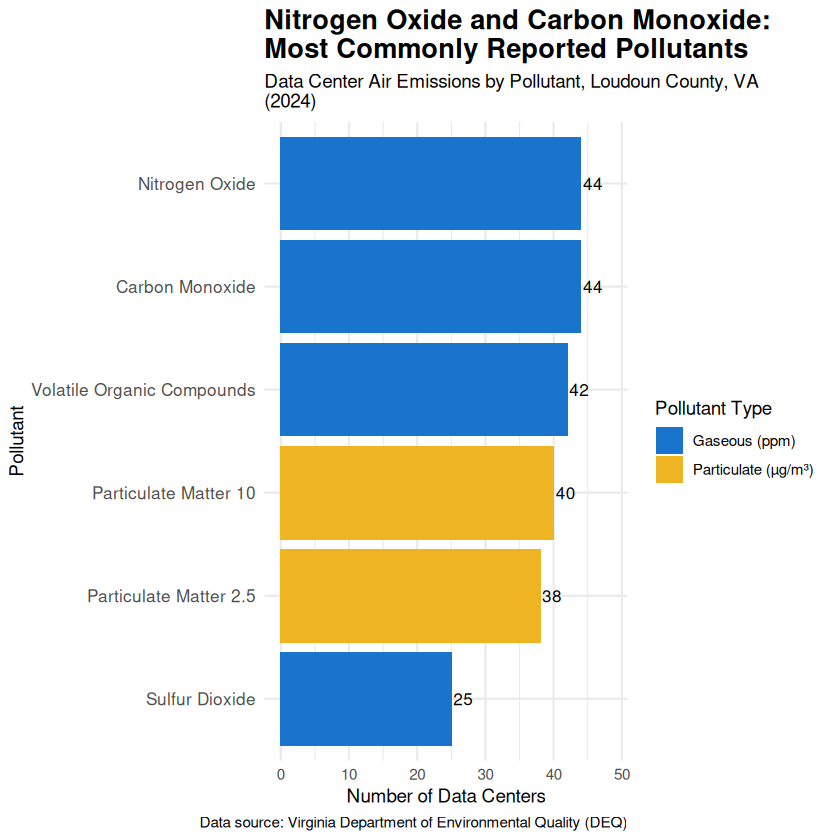

In [55]:
# Visualization 1: Distribution 

# Summarize the data

facility_counts <- air_emissions_joined %>%
  filter(!is.na(emission_value)) %>%      # selects the values that are available/NOT missing/excludes missing emissions
  filter(pollutant_name %in% c("Carbon Monoxide", "Nitrogen Oxide", "Sulfur Dioxide", "Volatile Organic Compounds", "Particulate Matter 10", "Particulate Matter 2.5")) %>% # excludes "Particulate Matter"  
  group_by(pollutant_name) %>%           
  summarise(num_datacenters = n_distinct(name), .groups = "drop") # removes the grouping after summarizing, so the output is a regular, ungrouped data frame; n_distinct is part of the dplyr package and counts the number of unique values in a vector

facility_counts


viz1 <- ggplot(facility_counts,
                aes(x = reorder(pollutant_name, num_datacenters), # reorder() to change the order of the factor levels
                    y = num_datacenters,
                    fill = ifelse(pollutant_name %in% 
                                  c("Carbon Monoxide", "Nitrogen Oxide",
                                    "Sulfur Dioxide", "Volatile Organic Compounds"),
                                  "Gaseous Pollutants",
                                  "Particulate Matter"))) +
  geom_col() +                            # geom_col()is part of the ggplot2 package 
  geom_text(aes(label = num_datacenters), # geom_text()is part of the ggplot2 package
            hjust = -0.1,
            size = 3.5) +
  scale_fill_manual(    # scale_fill_manual()is part of the ggplot2 package 
    values = c(
      "Gaseous Pollutants" = "dodgerblue3",
      "Particulate Matter" = "goldenrod2"), 
      labels = c("Gaseous (ppm)", "Particulate (µg/m³)"),
      name = "Pollutant Type"
  ) +
  coord_flip() +   # coord_flip()is part of the ggplot2 package
  labs(            # labs() is part of the ggplots2 package
    title = "Nitrogen Oxide and Carbon Monoxide:\nMost Commonly Reported Pollutants",
    subtitle = str_wrap("Data Center Air Emissions by Pollutant, Loudoun County, VA (2024)", width = 60),
    x = "Pollutant",
    y = "Number of Data Centers",
    caption = "Data source: Virginia Department of Environmental Quality (DEQ)"
  ) +
  theme_minimal() + # theme_minimal is part of the ggplot2 package and applies a clean, simplified visual style to the plot
  theme(
    axis.text.y = element_text(size = 10),
    plot.title = element_text(size = 16, face = "bold")
  ) +
  ylim(0, max(facility_counts$num_datacenters) * 1.1)

viz1


In [47]:
# Visualization 1: This bar chart shows the number of data centers in Loudoun County, VA emitting each pollutant in 2024. Among gaseous pollutants, nitrogen oxide and carbon monoxide are emitted by the greatest number of facilities; for particulate matter, the number of data centers emitting PM10 and PM2.5 is approximately the same. This visualization highlights which emissions may require closer monitoring given the higher number of data centers emitting those pollutants.

Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”


Warning message:
“Removed 3 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”


Warning message:
“Removed 2 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


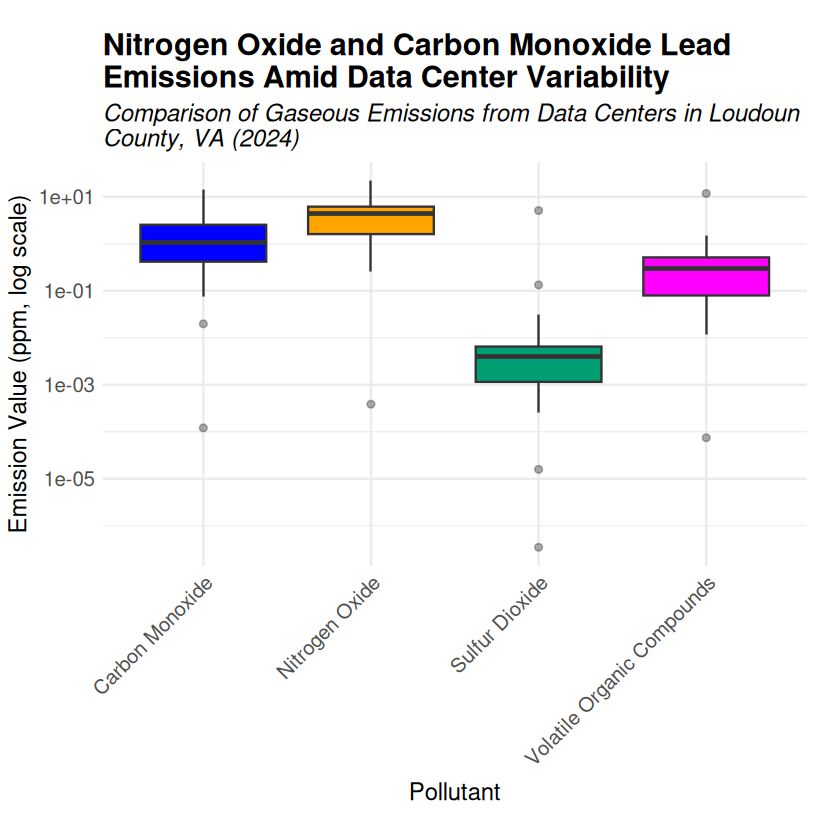

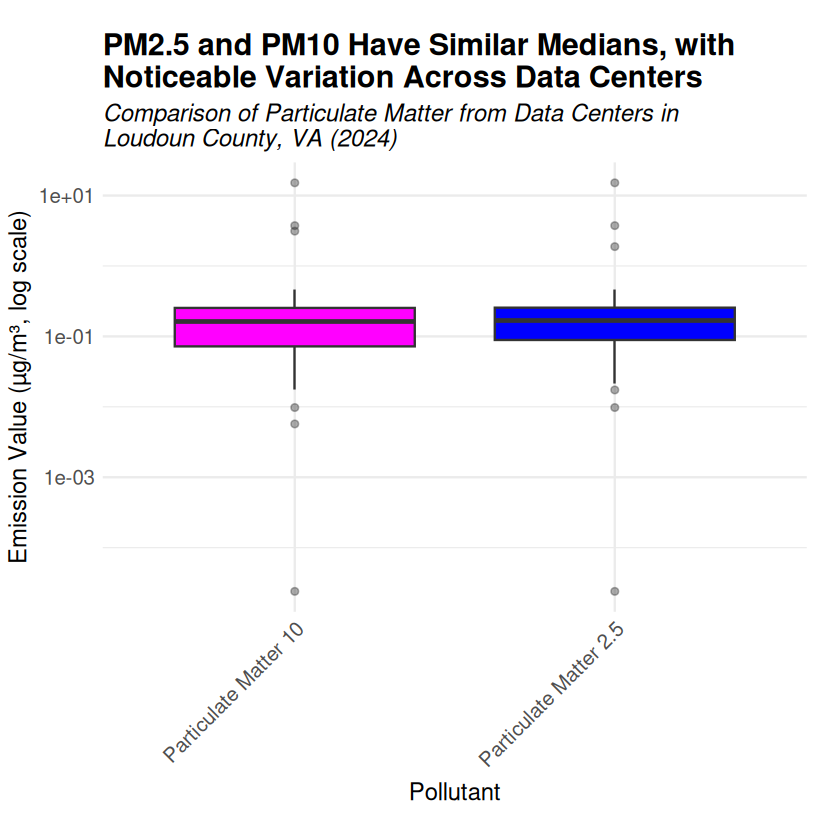

In [48]:
# Visualization 2
# Create two different datasets based on units of measurements
# Add units of measurement

gas_df <- air_emissions_joined %>%
  filter(pollutant_name %in% c("Carbon Monoxide",
                               "Nitrogen Oxide",
                               "Sulfur Dioxide",
                               "Volatile Organic Compounds"))

pm_df <- air_emissions_joined %>%
  filter(pollutant_name %in% c("Particulate Matter 2.5",
                               "Particulate Matter 10"))

#  Create Boxplot by Measurement Unit for gaseous pollutants, use log scale

viz2_gas <- ggplot(gas_df,
                   aes(x = pollutant_name,
                       y = emission_value,
                       fill = pollutant_name)) +
  geom_boxplot(outlier.alpha = 0.4) +
  scale_y_log10() +
  scale_fill_manual(values = c(
    "Carbon Monoxide" = "blue",   
    "Nitrogen Oxide" = "orange",    
    "Sulfur Dioxide" = "#009E73",     
    "Volatile Organic Compounds" = "magenta"  
  )) +
  labs(
    title = str_wrap ("Nitrogen Oxide and Carbon Monoxide Lead Emissions Amid Data Center Variability", width = 45),
    subtitle = str_wrap ("Comparison of Gaseous Emissions from Data Centers in Loudoun County, VA (2024)", width = 60),  
    x = "Pollutant",
    y = "Emission Value (ppm, log scale)"
  ) +
  theme_minimal() +
  theme(
  plot.margin = margin(t = 20, r = 20, b = 20, l = 5)
  )+
  theme(
    legend.position = "none",
    axis.text.x = element_text(angle = 45, hjust = 1),
    plot.title = element_text(size = 18, face = "bold"),
    plot.subtitle = element_text(size = 14, face = "italic"),
    axis.text = element_text(size = 12),
    axis.title = element_text(size = 14)
  )

# Create Boxplot by Measurement Unit for PM 2.5, and PM 10

viz2_pm <- ggplot(pm_df,
                  aes(x = pollutant_name,
                      y = emission_value,
                      fill = pollutant_name)) +
  geom_boxplot(outlier.alpha = 0.4) +
  scale_y_log10() +
  scale_fill_manual(values = c(                   
    "Particulate Matter 2.5" = "blue",               
    "Particulate Matter 10" = "magenta"                 
  )) +
  labs(
    title = str_wrap ("PM2.5 and PM10 Have Similar Medians, with Noticeable Variation Across Data Centers ", width = 45),
    subtitle = str_wrap ("Comparison of Particulate Matter from Data Centers in Loudoun County, VA (2024)", width = 60),  
    x = "Pollutant",
    y = "Emission Value (µg/m³, log scale)"
  ) +
  theme_minimal() +
  theme(
  plot.margin = margin(t = 20, r = 20, b = 20, l = 5)
  )+
  theme(
    legend.position = "none",
    axis.text.x = element_text(angle = 45, hjust = 1),
    plot.title = element_text(size = 18, face = "bold"),
    plot.subtitle = element_text(size = 14, face = "italic"),
    axis.text = element_text(size = 12),
    axis.title = element_text(size = 14)
  ) 

viz2_gas
viz2_pm


In [49]:
# Visualization 2: The boxplots show the distribution of emission values for pollutants across all data centers in Loudoun County in 2024. Among gaseous pollutants, carbon monoxide and nitrogen oxide exhibit higher median emissions (log scale), indicating that these pollutants are more consistently emitted at elevated levels across data centers; particulate matters PM 2.5 and PM 10 have approximately equal median emissions (log scale). While the variabilty is similar across pollutant types, some data centers appear to be extreme emitters of specific pollutants, which may warrant further investigation.

In [50]:
# Standarize the addresses in the air_emissions_joined and data_centers_clean (PEC) datasets

air_emissions_joined <- air_emissions_joined %>%
  mutate(address_clean = address %>%
           str_to_lower() %>%
          str_trim() %>%
          str_replace_all("\\.", "") %>%
          str_replace_all(" pl$", " plaza") %>%
          str_replace_all(" dr$", " drive") %>%
          str_replace_all(" rd$", " road") %>%
          str_replace_all(" ln$", " lane") %>%
          str_replace_all(" cir$", " circle") %>%
          str_replace_all(" pkwy$", " parkway"))

data_centers_clean <- data_centers_clean %>%
  mutate(address_clean = street_address %>%
          str_to_lower() %>%
          str_trim() %>%
          str_replace_all("\\.", "") %>%
          str_replace_all(" pl$", " plaza") %>%
          str_replace_all(" dr$", " drive") %>%
          str_replace_all(" rd$", " road") %>%
          str_replace_all(" ln$", " lane") %>%
          str_replace_all(" cir$", " circle") %>%
          str_replace_all(" pkwy$", " parkway"))

# Manually add in missing address

air_emissions_joined <- air_emissions_joined %>%
  mutate(address_clean = address_clean %>%
           str_replace_all(" plz$", " plaza") %>%
           str_replace_all("round table", "roundtable"))

data_centers_clean <- data_centers_clean %>%
  mutate(address_clean = address_clean %>%
           str_replace_all(" plz$", " plaza") %>%
           str_replace_all("round table", "roundtable"))

data_centers_clean <- data_centers_clean %>%
 mutate(address_clean = case_when(
  address_clean == "45900n pathfinder plaza" ~ "45900 pathfinder way",
   TRUE ~ address_clean
  ))

# Standardize Pathfinder address in emissions dataset
air_emissions_joined <- air_emissions_joined %>%
  mutate(address_clean = case_when(
    str_detect(address_clean, "^45900") &
    str_detect(address_clean, "pathfinder") ~ "45900 pathfinder plaza",
    TRUE ~ address_clean
  ))

# Standardize Pathfinder address in data centers dataset
data_centers_clean <- data_centers_clean %>%
  mutate(address_clean = case_when(
    str_detect(address_clean, "^45900") &
    str_detect(address_clean, "pathfinder") ~ "45900 pathfinder plaza",
    TRUE ~ address_clean
  ))


# Standardize Kipper address in emissions dataset
air_emissions_joined <- air_emissions_joined %>%
  mutate(address_clean = case_when(
    str_detect(address_clean, "^22370") &
    str_detect(address_clean, "kipper") ~ "22370 kipper drive",
    TRUE ~ address_clean
  ))

# Standardize Kipper address in data centers dataset
data_centers_clean <- data_centers_clean %>%
  mutate(address_clean = case_when(
    str_detect(address_clean, "^22370") &
    str_detect(address_clean, "kipper") ~ "22370 kipper drive",
    TRUE ~ address_clean
  ))

# Standarize Prologis address in emissions dataset

air_emissions_joined <- air_emissions_joined %>%
  mutate(address_clean = case_when(
    str_detect(address_clean, "^45220") &
    str_detect(address_clean, "prolog") ~ "45220 prologis plaza",
    TRUE ~ address_clean
  ))

# Standarize Prologis address in data centers dataset in data centers dataset

data_centers_clean <- data_centers_clean %>%
  mutate(address_clean = case_when(
    str_detect(address_clean, "^45220") &
    str_detect(address_clean, "prolog") ~ "45220 prologis plaza",
    TRUE ~ address_clean
  ))

# Check what doesn't match
setdiff(air_emissions_joined$address_clean,
        data_centers_clean$address_clean)

# Check that address_clean exists in both datasets
"address_clean" %in% colnames(air_emissions_joined)
"address_clean" %in% colnames(data_centers_clean)

# Create one address per data center in the data_centers_clean dataset removing duplicates
data_centers_coords <- data_centers_clean %>%
  select(address_clean, lat, long) %>%
  distinct(address_clean, .keep_all = TRUE)

# Check that each address appears only once in the data_centers_coords dataset
data_centers_coords %>%
  count(address_clean) %>%
  filter(n > 1)


[1] "21635 red rum drive"          "22001 loudoun county parkway"
 [3] "511 shaw road"                "42911 arcola road"           
 [5] "23825 erins run drive"        "22890 platform plaza"        
 [7] "22210 loudoun county parkway" "relocation drive"            
 [9] "22588 relocation drive"       "21099 atlantic boulevard"    
[11] "28755 relocation drive"       "42575 arcola blvd"           
[13] "19935 sycolin road"           "44254 import plaza"          
[15] "24282 quail ridge lane"       "45781 maries road"

[1] TRUE

[1] TRUE

address_clean,n
<chr>,<int>


In [51]:
# Join air_emissions_joined and data_centers_coords (PEC databese) datasets via address_clean so that the emissions_coordinates_joined dataset has longtitude and latitude columns

emissions_coordinates_joined <- air_emissions_joined %>%
  left_join(data_centers_coords, by = "address_clean")

glimpse (emissions_coordinates_joined)

# Remove coordinates with NAs
emissions_tidy <- emissions_coordinates_joined %>%
  drop_na(lat, long)

# Check removal worked - second number should be smaller than the firest week
nrow(emissions_coordinates_joined)
nrow(emissions_tidy)

sum(is.na(emissions_tidy$lat))

Rows: 240
Columns: 11
$ name              <chr> "Equinix LLC", "Equinix LLC", "Equinix LLC", "Equini…
$ address           <chr> "44470 Chilum Pl", "44470 Chilum Pl", "44470 Chilum …
$ city              <chr> "Ashburn", "Ashburn", "Ashburn", "Ashburn", "Ashburn…
$ principal_product <chr> "data center", "data center", "data center", "data c…
$ icis_id           <chr> "VA0000005110700820", "VA0000005110700820", "VA00000…
$ emissionsyear     <int> 2024, 2024, 2024, 2024, 2024, 2024, 2024, 2024, 2024…
$ emission_value    <dbl> 0.55391400, 0.02376000, 0.02904000, 0.03062400, 0.10…
$ pollutant_name    <chr> "Nitrogen Oxide", "Particulate Matter", "Volatile Or…
$ address_clean     <chr> "44470 chilum plaza", "44470 chilum plaza", "44470 c…
$ lat               <dbl> 39.02221, 39.02221, 39.02221, 39.02221, 39.02221, 39…
$ long              <dbl> -77.46144, -77.46144, -77.46144, -77.46144, -77.4614…


[1] 240

[1] 154

[1] 0

In [52]:
# Continue cleaning dataset
# Identify unmatched emissions rows

unmatched_emissions <- emissions_coordinates_joined %>%
  filter(is.na(lat) | is.na(long))

unmatched_emissions %>%
  distinct(address_clean)

# Inspect columns 

unique(emissions_coordinates_joined$lat)

sum(is.na(emissions_coordinates_joined$lat))
sum(is.na(emissions_coordinates_joined$long))


address_clean
<chr>
21635 red rum drive
22001 loudoun county parkway
511 shaw road
42911 arcola road
23825 erins run drive
22890 platform plaza
22210 loudoun county parkway
relocation drive
22588 relocation drive


[1] 39.02221       NA 39.02266 39.02088 39.00454 39.02908 39.02490 39.01815
 [9] 39.00305 38.96118 39.01851 39.01003 38.99910 38.99797 39.01394 38.95866
[17] 38.98775 39.00663 38.99014 38.99804 38.99696 38.94984 39.05171 39.02125
[25] 39.00060 39.03563 38.98216 39.01186

[1] 86

[1] 86

Reading layer `Loudoun_County_Boundary' from data source 
  `/home/user/Capstone/data_center_research_r/data/raw_data/Loudoun_County_Boundary.geojson' 
  using driver `GeoJSON'
Simple feature collection with 1 feature and 6 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: -77.9622 ymin: 38.84621 xmax: -77.32831 ymax: 39.3246
Geodetic CRS:  WGS 84


Reading layer `Loudoun_Water_Bodies' from data source 
  `/home/user/Capstone/data_center_research_r/data/raw_data/Loudoun_Water_Bodies.geojson' 
  using driver `GeoJSON'
Simple feature collection with 6042 features and 9 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -77.95354 ymin: 38.83887 xmax: -77.31833 ymax: 39.32859
Geodetic CRS:  WGS 84


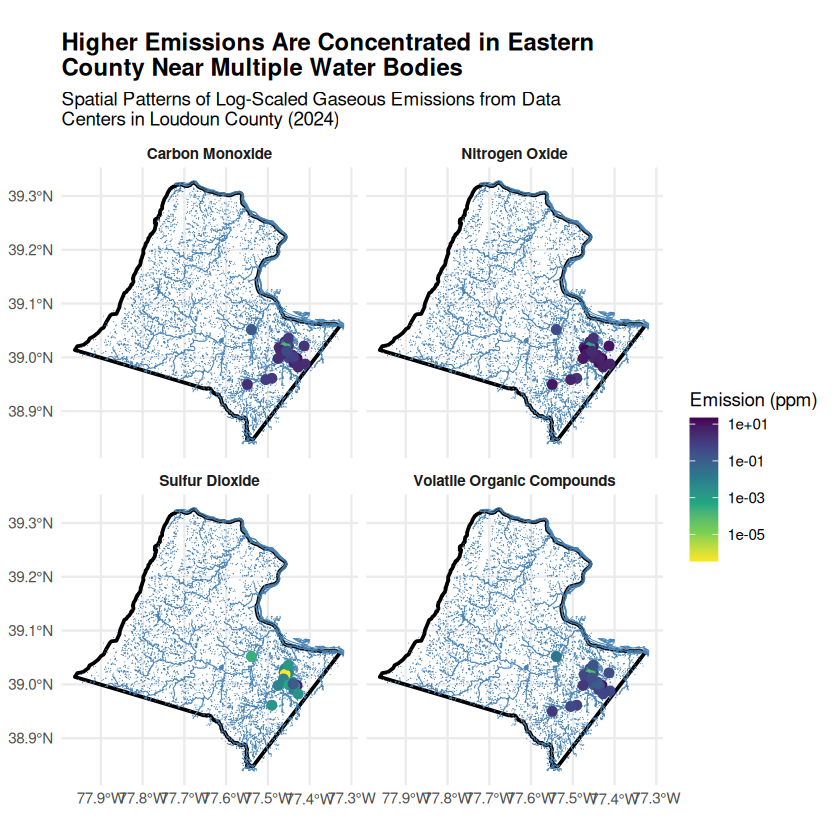

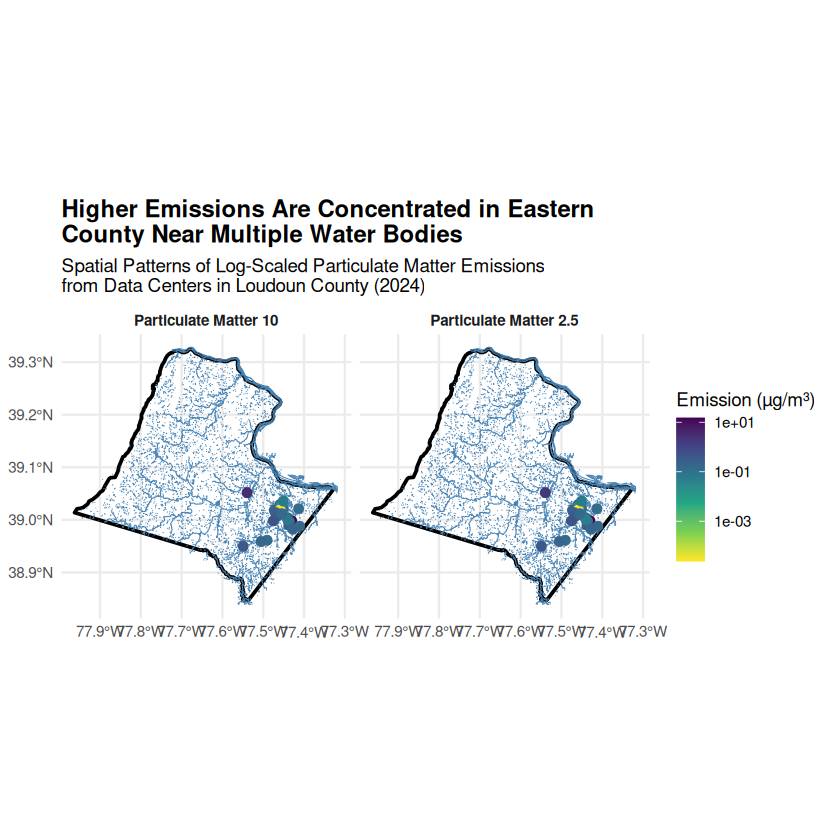

In [53]:
# Load the Loundoun boundary geojson file from local data

boundary <- st_read("/home/user/Capstone/data_center_research_r/data/raw_data/Loudoun_County_Boundary.geojson")

# Load the Loundoun waterbodies geojson file from local data

water_bodies <- st_read("/home/user/Capstone/data_center_research_r/data/raw_data/Loudoun_Water_Bodies.geojson")

  # Water bodies
  #geom_sf(
   # data = water_bodies,
   # fill = "lightblue",
   # color = "dodgerblue4",
   # alpha = 0.6
  #) 

# Convert points (latitude and longitude of data centers) to spatial features using st_as_sf()

emissions_sf <- st_as_sf(
  emissions_tidy,
  coords = c("long", "lat"),  # X first, Y second
  crs = 4326                  # WGS84 (standard GPS)
)

# Add units of measurement. 

emissions_sf <- emissions_sf %>%
  mutate(
    measurement_unit = case_when(
      pollutant_name %in% c("Carbon Monoxide",
                            "Nitrogen Oxide",
                            "Sulfur Dioxide",
                            "Volatile Organic Compounds") ~ "ppm",
      pollutant_name %in% c(
                            "Particulate Matter 2.5",
                            "Particulate Matter 10") ~ "µg/m³",
      TRUE ~ NA_character_
    )
  )

# Create combined facet label
emissions_sf <- emissions_sf %>%
  mutate(pollutant_label = paste0(pollutant_name, "(", measurement_unit, ")")) # 

# Convert to factor with specific order
emissions_sf <- emissions_sf %>%
  mutate(pollutant_label = factor(  # Must create pollutant_label first. Cannot factor it before it exists.)
    pollutant_label,
    levels = c(
      "Carbon Monoxide (ppm)",
      "Nitrogen Oxide (ppm)",
      "Sulfur Dioxide (ppm)",
      "Volatile Organic Compounds (ppm)",
      "Particulate Matter 2.5 (µg/m³)",
      "Particulate Matter 10 (µg/m³)"
    )
  ))

# Split datasets by measurement unit

emissions_gas <- emissions_sf %>%
  filter(measurement_unit == "ppm")

emissions_pm <- emissions_sf %>%
  filter(measurement_unit == "µg/m³")

# Map Gaseous Emissions 

viz3_map_gas <- ggplot() +
  geom_sf(data = boundary, fill = NA, color = "black", linewidth = 0.8) +
  geom_sf(data = water_bodies, fill = "lightblue", color = "steelblue", alpha = 0.2) +
  geom_sf(
    data = emissions_gas,
    aes(color = emission_value),
    size = 2
  ) +
 facet_wrap(~ pollutant_name) +
  scale_color_viridis_c(
    option = "viridis",
    trans = "log10",
    direction = -1, # reverses color scheme so dark color can reflect higher emission levels
    name = "Emission (ppm)"
  ) +
  theme_minimal() +
  labs(
    title = str_wrap ("Higher Emissions Are Concentrated in Eastern County Near Multiple Water Bodies", width = 45),
    subtitle = str_wrap ("Spatial Patterns of Log-Scaled Gaseous Emissions from Data Centers in Loudoun County (2024)", width = 60) 
  ) +
  theme(
    strip.text = element_text(face = "bold"),
    plot.title = element_text(face = "bold", size = 14)
  )

print(viz3_map_gas)

# Map Particulate Emissions 

viz3_map_pm <- ggplot() +
  geom_sf(data = boundary, fill = NA, color = "black", linewidth = 0.8) +
  geom_sf(data = water_bodies, fill = "lightblue", color = "steelblue", alpha = 0.2) +
  geom_sf(
    data = emissions_pm,
    aes(color = emission_value),
    size = 2
  ) +
  facet_wrap(~ pollutant_name) +
  scale_color_viridis_c(
    option = "viridis",
    trans = "log10",
    direction = -1, # reverses color scheme so dark color can reflect higher emission levels
    name = "Emission (µg/m³)"
  ) +
  theme_minimal() +
  labs(
    title = str_wrap ("Higher Emissions Are Concentrated in Eastern County Near Multiple Water Bodies", width = 45),
    subtitle = str_wrap ("Spatial Patterns of Log-Scaled Particulate Matter Emissions from Data Centers in Loudoun County (2024)", width = 60) 
  ) +
  theme(
    strip.text = element_text(face = "bold"),
    plot.title = element_text(face = "bold", size = 14)
  )

print(viz3_map_pm)



In [54]:
Visualization #3: The spatial distribution maps indicate that reported emissions from data centers are concentrated in the eastern portion of Loudoun County, with several facilities located near water bodies. Higher emission values appear clustered in this area across multiple pollutants. These spatial patterns highlight areas where additional monitoring or environmental assessment may be appropriate given the proximity of emission sources to waterways.

ERROR: Error: object 'Visualization' not found
